# Geometric mean product tests

The tests cover:

- a deterministic nonsingular case using two independent means,
- random product, direction, and scalar-descent checks,
- ordinary principal-relative branch selection,
- the deterministic antipodal branch choice,
- propagation of nonfinite inputs, and
- invariance of the selected branch under positive rescaling.

In [1]:
import os
from pathlib import Path
import importlib.util
import sys

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import torch

LOCAL_CANDIDATES = [
    Path.cwd().resolve() / "geometric_mean.py",
    Path.cwd().resolve() / "upload" / "geometric_mean.py",
]
LOCAL_MODULE = next((path for path in LOCAL_CANDIDATES if path.exists()), None)
if LOCAL_MODULE is not None:
    spec = importlib.util.spec_from_file_location("local_geometric_mean", LOCAL_MODULE)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    aligned_geom_mean_torch = module.aligned_geom_mean_torch
else:
    PROJECT_ROOT = Path.cwd().resolve()
    while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src" / "utils" / "common.py").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    SRC_DIR = PROJECT_ROOT / "src"
    if str(SRC_DIR) not in sys.path:
        sys.path.insert(0, str(SRC_DIR))
    from algorithms.geometric_mean import aligned_geom_mean_torch

In [2]:
torch.manual_seed(7)
dtype = torch.complex64
real_dtype = torch.float32


def as_complex_tensor(value):
    return torch.as_tensor(value, dtype=dtype)


def relative_error(value: torch.Tensor, target: torch.Tensor, eps: float = 1e-30) -> torch.Tensor:
    return torch.abs(value - target) / torch.clamp(torch.abs(target), min=eps)


def scalar_regularized_updates(q, z, d=-1.0 + 0.0j, u_q=0.0, u_z=0.0):
    q = as_complex_tensor(q)
    z = as_complex_tensor(z)
    d = as_complex_tensor(d)
    u_q = torch.as_tensor(u_q, dtype=real_dtype)
    u_z = torch.as_tensor(u_z, dtype=real_dtype)

    residual = d - q * z
    z_plus = z + torch.conj(q) * residual / (torch.abs(q).square() + u_q)
    q_plus = q + torch.conj(z) * residual / (torch.abs(z).square() + u_z)
    q_tilde = aligned_geom_mean_torch(q, q_plus)
    z_tilde = aligned_geom_mean_torch(z, z_plus)

    return {
        "q": q,
        "z": z,
        "d": d,
        "q_plus": q_plus,
        "z_plus": z_plus,
        "q_tilde": q_tilde,
        "z_tilde": z_tilde,
        "q_plus_z": q_plus * z,
        "q_z_plus": q * z_plus,
        "tilde_product": q_tilde * z_tilde,
    }


def format_complex(name: str, value: torch.Tensor) -> str:
    scalar = complex(value.detach().cpu().item())
    phase = np.angle(scalar)
    return (
        f"{name:>13s}: phase={phase:+.3e} rad, "
        f"abs={abs(scalar):.8f}, value={scalar.real:+.8f}{scalar.imag:+.8f}j"
    )

## Test 1: Near-Branch Nonsingular Inputs

This exercises two independently computed geometric means close to, but not exactly on, the square-root branch cut. The exact antipodal regression is tested separately below.

In [3]:
case = scalar_regularized_updates(
    q=1.0 * np.exp(1j * 0.1),
    z=1.0 * np.exp(1j * (-0.1)),
    d=-1.0,
    u_q=0.4,
    u_z=0.4,
)

for key in ["q", "z", "q_plus", "z_plus", "q_tilde", "z_tilde", "q_plus_z", "q_z_plus", "tilde_product", "d"]:
    print(format_complex(key, case[key]))

condition_error = torch.maximum(
    relative_error(case["q_plus_z"], case["d"]),
    relative_error(case["q_z_plus"], case["d"]),
)
product_error = relative_error(case["tilde_product"], case["d"])

print(f"condition error: {condition_error.item():.3e}")
current_error = relative_error(case["q"] * case["z"], case["d"])

print(f"GM product error: {product_error.item():.3e}")
assert product_error <= condition_error + 5e-6
assert product_error < current_error


            q: phase=+1.000e-01 rad, abs=1.00000001, value=+0.99500418+0.09983341j
            z: phase=-1.000e-01 rad, abs=1.00000001, value=+0.99500418-0.09983341j
       q_plus: phase=-3.042e+00 rad, abs=0.42857142, value=-0.42643034-0.04278575j
       z_plus: phase=+3.042e+00 rad, abs=0.42857142, value=-0.42643034+0.04278575j
      q_tilde: phase=+1.671e+00 rad, abs=0.65465370, value=-0.06535631+0.65138316j
      z_tilde: phase=+1.471e+00 rad, abs=0.65465370, value=+0.06535631+0.65138316j
     q_plus_z: phase=-3.142e+00 rad, abs=0.42857143, value=-0.42857143-0.00000000j
     q_z_plus: phase=+3.142e+00 rad, abs=0.42857143, value=-0.42857143+0.00000000j
tilde_product: phase=+3.142e+00 rad, abs=0.42857146, value=-0.42857146+0.00000000j
            d: phase=+3.142e+00 rad, abs=1.00000000, value=-1.00000000+0.00000000j
condition error: 5.714e-01
GM product error: 5.714e-01


## Plot: Near-Branch Case

Visualizes the same failure-prone case from Test 1. Solid arrows show the actual complex values, while dotted rays show the corresponding unit directions for small-magnitude values. The text panel prints the exact phases, magnitudes, values, and errors used in the plot.


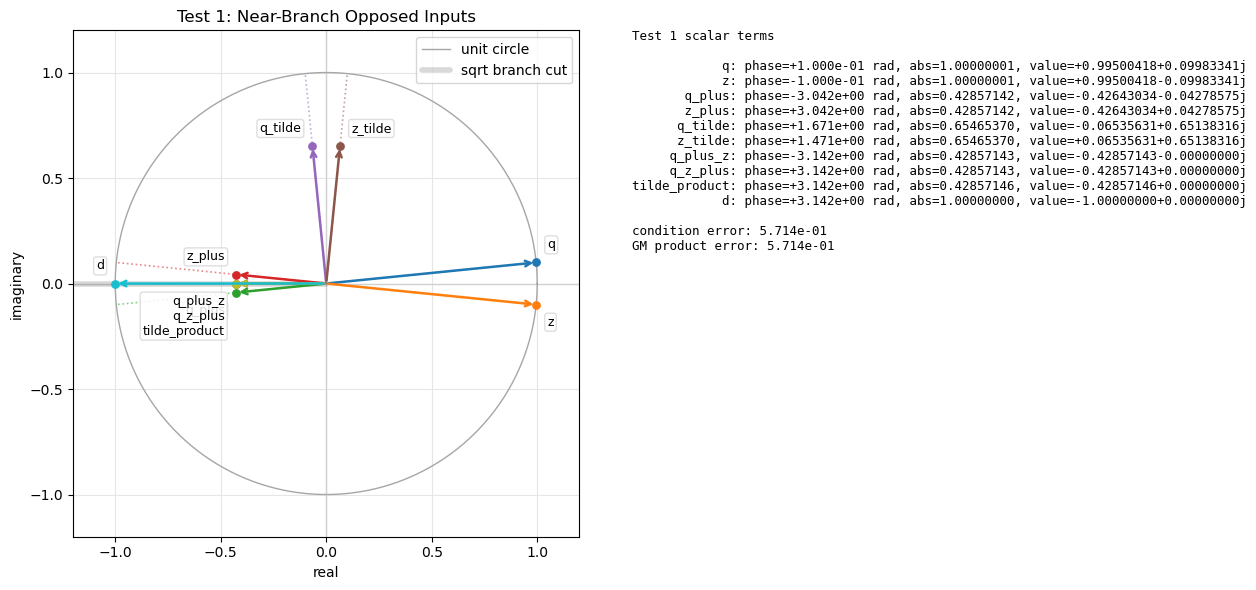

In [4]:
near_branch_names = [
    "q",
    "z",
    "q_plus",
    "z_plus",
    "q_tilde",
    "z_tilde",
    "q_plus_z",
    "q_z_plus",
    "tilde_product",
    "d",
]
near_branch_values = {
    name: complex(case[name].detach().cpu().item())
    for name in near_branch_names
}

fig, (ax, text_ax) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    gridspec_kw={"width_ratios": [1.25, 1.0]},
)

max_radius = max(1.0, *(abs(value) for value in near_branch_values.values()))
plot_radius = 1.2 * max_radius
theta = np.linspace(0.0, 2.0 * np.pi, 512, dtype=np.float32)

ax.axhline(0.0, color="0.82", linewidth=1.0)
ax.axvline(0.0, color="0.82", linewidth=1.0)
ax.plot(np.cos(theta), np.sin(theta), color="0.65", linewidth=1.0, label="unit circle")
ax.plot(
    [-plot_radius, 0.0],
    [0.0, 0.0],
    color="black",
    linewidth=4.0,
    alpha=0.15,
    solid_capstyle="round",
    label="sqrt branch cut",
)

for index, (name, value) in enumerate(near_branch_values.items()):
    color = f"C{index % 10}"
    magnitude = abs(value)
    unit_value = value / magnitude if magnitude > 0.0 else 0.0j
    ax.plot(
        [0.0, unit_value.real],
        [0.0, unit_value.imag],
        color=color,
        linestyle=":",
        linewidth=1.2,
        alpha=0.55,
    )
    ax.annotate(
        "",
        xy=(value.real, value.imag),
        xytext=(0.0, 0.0),
        arrowprops={"arrowstyle": "->", "color": color, "linewidth": 1.8},
    )
    ax.scatter(value.real, value.imag, color=color, s=28, zorder=3)

label_groups = []
for name, value in near_branch_values.items():
    for group in label_groups:
        if abs(value - group["value"]) < 5e-6:
            group["names"].append(name)
            break
    else:
        label_groups.append({"value": value, "names": [name]})

for group in label_groups:
    value = group["value"]
    label = "\n".join(group["names"])
    x_offset = 8 if value.real >= 0.0 else -8
    y_offset = 8 if value.imag >= 0.0 else -8
    ax.annotate(
        label,
        xy=(value.real, value.imag),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        ha="left" if value.real >= 0.0 else "right",
        va="bottom" if value.imag >= 0.0 else "top",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.2", "facecolor": "white", "edgecolor": "0.85", "alpha": 0.85},
    )

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-plot_radius, plot_radius)
ax.set_ylim(-plot_radius, plot_radius)
ax.set_xlabel("real")
ax.set_ylabel("imaginary")
ax.set_title("Test 1: Near-Branch Opposed Inputs")
ax.grid(True, color="0.9", linewidth=0.8)
ax.legend(loc="upper right")

near_branch_condition_error = torch.maximum(
    relative_error(case["q_plus_z"], case["d"]),
    relative_error(case["q_z_plus"], case["d"]),
)
near_branch_product_error = relative_error(case["tilde_product"], case["d"])
summary_lines = [
    "Test 1 scalar terms",
    "",
    *(format_complex(name, case[name]) for name in near_branch_names),
    "",
    f"condition error: {near_branch_condition_error.item():.3e}",
    f"GM product error: {near_branch_product_error.item():.3e}",
]

text_ax.axis("off")
text_ax.text(
    0.0,
    1.0,
    "\n".join(summary_lines),
    ha="left",
    va="top",
    family="monospace",
    fontsize=9,
)

fig.tight_layout()


## Test 2: General Well-Conditioned Product Consistency

Random complex `q`, `z`, and `d` values with random regularization sampled from `u_q in (0, |q|^2)` and `u_z in (0, |z|^2)`. A case fails only if `q_tilde*z_tilde` points at least 90 degrees away from either `q_plus*z` or `z_plus*q`. This directly checks that the geometric-mean product chooses the direction between the two regularized product updates instead of the opposite square-root branch.

In [5]:
num_candidates = 65536
num_samples = 4096
rng = torch.Generator().manual_seed(42)

def random_complex(shape, min_abs=0.4, max_abs=1.8):
    amp = min_abs + (max_abs - min_abs) * torch.rand(shape, dtype=real_dtype, generator=rng)
    phase = 2.0 * torch.pi * torch.rand(shape, dtype=real_dtype, generator=rng) - torch.pi
    return torch.complex(amp * torch.cos(phase), amp * torch.sin(phase)).to(dtype)

def unit_complex(value: torch.Tensor, eps: float = 1e-30) -> torch.Tensor:
    return value / torch.clamp(torch.abs(value), min=eps)

def direction_alignment(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-30) -> torch.Tensor:
    return (unit_complex(a, eps) * torch.conj(unit_complex(b, eps))).real

def angle_degrees(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-30) -> torch.Tensor:
    alignment = torch.clamp(direction_alignment(a, b, eps), -1.0, 1.0)
    return torch.rad2deg(torch.acos(alignment))

q = random_complex((num_candidates,))
z = random_complex((num_candidates,))
d = random_complex((num_candidates,))
u_floor = torch.finfo(real_dtype).eps
u_q_fraction = torch.rand((num_candidates,), dtype=real_dtype, generator=rng).clamp_min(u_floor)
u_z_fraction = torch.rand((num_candidates,), dtype=real_dtype, generator=rng).clamp_min(u_floor)
u_q = u_q_fraction * torch.abs(q).square()
u_z = u_z_fraction * torch.abs(z).square()
assert torch.all((0.0 < u_q) & (u_q < torch.abs(q).square()))
assert torch.all((0.0 < u_z) & (u_z < torch.abs(z).square()))

regularized_cases = scalar_regularized_updates(q=q, z=z, d=d, u_q=u_q, u_z=u_z)
all_q_plus_z = regularized_cases["q_plus_z"]
all_z_plus_q = regularized_cases["q_z_plus"]
all_tilde_product = regularized_cases["tilde_product"]

product_pair_alignment_all = direction_alignment(all_q_plus_z, all_z_plus_q)
product_pair_angle_all = angle_degrees(all_q_plus_z, all_z_plus_q)
tilde_to_q_plus_z_angle_all = angle_degrees(all_tilde_product, all_q_plus_z)
tilde_to_z_plus_q_angle_all = angle_degrees(all_tilde_product, all_z_plus_q)
max_tilde_angle_all = torch.maximum(tilde_to_q_plus_z_angle_all, tilde_to_z_plus_q_angle_all)
non_tiny = (
    (torch.abs(all_q_plus_z) > 1e-10)
    & (torch.abs(all_z_plus_q) > 1e-10)
    & (torch.abs(all_tilde_product) > 1e-10)
)
direction_pass = (
    non_tiny
    & (tilde_to_q_plus_z_angle_all < 90.0)
    & (tilde_to_z_plus_q_angle_all < 90.0)
)
failed = torch.nonzero(non_tiny & ~direction_pass).flatten()
passed = torch.nonzero(direction_pass).flatten()
degenerate = torch.nonzero(~non_tiny).flatten()

tested = passed[:num_samples]
q_plus_z = all_q_plus_z[tested]
z_plus_q = all_z_plus_q[tested]
tilde_product = all_tilde_product[tested]
product_pair_alignment = product_pair_alignment_all[tested]
tilde_to_q_plus_z_angle = tilde_to_q_plus_z_angle_all[tested]
tilde_to_z_plus_q_angle = tilde_to_z_plus_q_angle_all[tested]
max_tilde_angle = max_tilde_angle_all[tested]

shared_direction = unit_complex(unit_complex(q_plus_z) + unit_complex(z_plus_q))
tilde_to_shared_direction = direction_alignment(tilde_product, shared_direction)
tilde_to_q_plus_z = direction_alignment(tilde_product, q_plus_z)
tilde_to_z_plus_q = direction_alignment(tilde_product, z_plus_q)
squared_product_error_all = relative_error(all_tilde_product.square(), all_q_plus_z * all_z_plus_q)
squared_product_error = relative_error(tilde_product.square(), q_plus_z * z_plus_q)

print(f"non-tiny candidates: {non_tiny.sum().item()} / {num_candidates}")
print(f"direction-pass candidates: {passed.numel()} / {num_candidates}")
print(f"direction-failed candidates: {failed.numel()} / {num_candidates}")
print(f"degenerate candidates skipped: {degenerate.numel()} / {num_candidates}")
print(f"tested direction-pass cases: {tested.numel()}")
print(f"min direction alignment q_plus*z vs z_plus*q: {product_pair_alignment.min().item():.6f}")
print(f"max angle q_plus*z vs z_plus*q: {product_pair_angle_all[non_tiny].max().item():.6f} deg")
print(f"min direction alignment q_tilde*z_tilde vs shared direction: {tilde_to_shared_direction.min().item():.6f}")
print(f"min direction alignment q_tilde*z_tilde vs q_plus*z: {tilde_to_q_plus_z.min().item():.6f}")
print(f"min direction alignment q_tilde*z_tilde vs z_plus*q: {tilde_to_z_plus_q.min().item():.6f}")
print(f"max angle q_tilde*z_tilde vs q_plus*z: {tilde_to_q_plus_z_angle_all[non_tiny].max().item():.6f} deg")
print(f"max angle q_tilde*z_tilde vs z_plus*q: {tilde_to_z_plus_q_angle_all[non_tiny].max().item():.6f} deg")
print(f"max tested angle to either product: {max_tilde_angle.max().item():.6f} deg")
print(f"max squared product error: {squared_product_error_all.max().item():.3e}")

assert degenerate.numel() == 0
assert failed.numel() == 0
assert tested.numel() == num_samples
assert tilde_to_q_plus_z_angle_all[non_tiny].max() < 90.0
assert tilde_to_z_plus_q_angle_all[non_tiny].max() < 90.0
assert tilde_to_shared_direction.min() > 1.0 - 5e-6
assert squared_product_error_all.max() < 5e-6

current_residual_all = torch.abs(q * z - d)
endpoint_bound_all = torch.maximum(
    torch.abs(all_q_plus_z - d),
    torch.abs(all_z_plus_q - d),
)
gm_residual_all = torch.abs(all_tilde_product - d)
normalized_descent_violation = (
    gm_residual_all - endpoint_bound_all
) / torch.clamp(current_residual_all, min=1e-30)
print(f"max normalized scalar-descent violation: {normalized_descent_violation.max().item():.3e}")
assert normalized_descent_violation.max() < 5e-6
assert torch.all(gm_residual_all < current_residual_all)

non-tiny candidates: 65536 / 65536
direction-pass candidates: 65536 / 65536
direction-failed candidates: 0 / 65536
degenerate candidates skipped: 0 / 65536
tested direction-pass cases: 4096
min direction alignment q_plus*z vs z_plus*q: -0.999989
max angle q_plus*z vs z_plus*q: 180.000000 deg
min direction alignment q_tilde*z_tilde vs shared direction: 1.000000
min direction alignment q_tilde*z_tilde vs q_plus*z: 0.002331
min direction alignment q_tilde*z_tilde vs z_plus*q: 0.002331
max angle q_tilde*z_tilde vs q_plus*z: 89.996803 deg
max angle q_tilde*z_tilde vs z_plus*q: 89.996803 deg
max tested angle to either product: 89.866455 deg
max squared product error: 9.880e-07
max normalized scalar-descent violation: -2.109e-06


In [6]:
# Ordinary principal-relative branch away from the exact antipodal tie.
branch_case = scalar_regularized_updates(
    q=1.0 + 0.0j,
    z=1.0 + 0.0j,
    d=-9.0 + 0.1j,
    u_q=1.0 / 9.0,
    u_z=1.0 / 9.0,
)
assert (branch_case["q_tilde"] * torch.conj(branch_case["q"])).real >= 0
assert (branch_case["z_tilde"] * torch.conj(branch_case["z"])).real >= 0
assert torch.abs(branch_case["tilde_product"] - branch_case["d"]) < torch.abs(branch_case["q"] * branch_case["z"] - branch_case["d"])
print("ordinary principal-relative branch passed")

ordinary principal-relative branch passed


In [7]:
# Branch selection must be independent of a common positive scale.
a = as_complex_tensor(1.0 + 0.0j)
b = as_complex_tensor(-1.0j)
scale = torch.as_tensor(1.0e-8, dtype=real_dtype)
gm_unscaled = aligned_geom_mean_torch(a, b)
gm_scaled = aligned_geom_mean_torch(scale * a, scale * b) / scale
assert torch.allclose(gm_scaled, gm_unscaled, rtol=5e-6, atol=5e-6)
assert (gm_scaled * torch.conj(a)).real > 0
print("positive-scale branch invariance passed")

positive-scale branch invariance passed


In [8]:
# Exact antipodal regression: both independent means must take the same
# positive-relative-imaginary branch.
tie_case = scalar_regularized_updates(
    q=np.exp(1j * 0.1),
    z=np.exp(-1j * 0.1),
    d=-1.0,
    u_q=0.4,
    u_z=0.4,
)
assert (tie_case["q_tilde"] * torch.conj(tie_case["q"])).imag > 0
assert (tie_case["z_tilde"] * torch.conj(tie_case["z"])).imag > 0
assert torch.allclose(
    tie_case["tilde_product"],
    as_complex_tensor(-3.0 / 7.0),
    rtol=5e-6,
    atol=5e-6,
)
print("exact antipodal branch regression passed")

exact antipodal branch regression passed


In [9]:
# Invalid local estimates must remain visible rather than becoming zeros.
nonfinite = aligned_geom_mean_torch(
    torch.tensor([complex(float("nan"), 0.0), 0j], dtype=dtype),
    torch.tensor([1 + 0j, complex(float("nan"), 0.0)], dtype=dtype),
)
assert torch.all(~torch.isfinite(nonfinite))
print("nonfinite propagation passed")

nonfinite propagation passed
